In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv(r"C:\Users\ramya\OneDrive\Desktop\Stock Market prediction project\apple_feature_engineered.csv")


In [3]:
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,MA20,MA50,Target,...,Negative_Sentiment,Neutral_Sentiment,article_count,Lag1,Lag2,Lag3,Lag5,RSI,MACD,Signal_Line
0,2017-10-05,36.193485,36.205132,35.881373,35.911650,85135200,0.012445,36.335905,36.659574,36.172497,...,0.008,0.925,1.0,35.748585,35.981518,35.825451,35.702003,38.064917,-0.284222,-0.258333
1,2017-11-27,40.694866,40.926288,40.519548,40.919275,82867200,-0.005029,40.163732,37.868176,40.456429,...,0.008,0.926,1.0,40.900558,40.898220,40.472790,39.773842,51.324818,0.770903,0.825436
2,2017-11-30,40.171238,40.239026,39.374124,39.839299,166108800,0.013984,40.322109,38.067460,39.984238,...,0.021,0.804,1.0,39.617229,40.456429,40.694866,40.898220,42.328513,0.570635,0.728934
3,2018-01-31,39.138016,39.374113,38.920623,39.007112,129915600,0.002755,40.695436,40.410276,39.219841,...,0.009,0.937,1.0,39.030506,39.261925,40.091763,40.725227,33.186061,-0.231234,0.065413
4,2018-03-16,41.783184,42.041364,41.689298,41.931049,157618800,-0.003526,41.453182,40.421219,41.144764,...,0.011,0.917,1.0,41.931046,41.881760,42.240883,42.243217,47.417043,0.583631,0.574672


In [4]:
df.shape

(1132, 22)

In [5]:
df.columns.tolist()

['Date',
 'Close',
 'High',
 'Low',
 'Open',
 'Volume',
 'Daily_Return',
 'MA20',
 'MA50',
 'Target',
 'Sentiment',
 'Positive_Sentiment',
 'Negative_Sentiment',
 'Neutral_Sentiment',
 'article_count',
 'Lag1',
 'Lag2',
 'Lag3',
 'Lag5',
 'RSI',
 'MACD',
 'Signal_Line']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1132 entries, 0 to 1131
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                1132 non-null   str    
 1   Close               1132 non-null   float64
 2   High                1132 non-null   float64
 3   Low                 1132 non-null   float64
 4   Open                1132 non-null   float64
 5   Volume              1132 non-null   int64  
 6   Daily_Return        1132 non-null   float64
 7   MA20                1132 non-null   float64
 8   MA50                1132 non-null   float64
 9   Target              1132 non-null   float64
 10  Sentiment           1132 non-null   float64
 11  Positive_Sentiment  1132 non-null   float64
 12  Negative_Sentiment  1132 non-null   float64
 13  Neutral_Sentiment   1132 non-null   float64
 14  article_count       1132 non-null   float64
 15  Lag1                1132 non-null   float64
 16  Lag2             

In [7]:
df.describe()

,Close,High,Low,Open,Volume,Daily_Return,MA20,MA50,Target,Sentiment,...,Negative_Sentiment,Neutral_Sentiment,article_count,Lag1,Lag2,Lag3,Lag5,RSI,MACD,Signal_Line
count,1132.000000,1132.000000,1132.000000,1132.000000,1.132000e+03,1132.000000,1132.000000,1132.000000,1132.000000,1132.000000,...,1132.000000,1132.000000,1132.000000,1132.000000,1132.000000,1132.000000,1132.000000,1132.000000,1132.000000,1132.000000
mean,153.958511,155.502665,152.271926,153.835533,8.419682e+07,0.000869,152.848249,151.008340,154.100646,0.528199,...,0.039040,0.863554,23.469081,153.844006,153.713492,153.611194,153.378700,53.871709,0.846677,0.855682
std,39.430958,39.603177,39.180646,39.379660,4.347879e+07,0.018115,38.957069,38.339682,39.426495,0.301629,...,0.018703,0.027994,15.953179,39.398458,39.379251,39.349194,39.319291,17.351850,2.767064,2.596006
min,33.736988,34.574540,33.691907,34.161694,2.404830e+07,-0.099608,36.335905,36.659574,35.177204,-0.993000,...,0.000000,0.666500,1.000000,35.748585,35.981518,35.825451,35.702003,3.180307,-6.476916,-5.642772
25%,132.329697,133.430185,130.419604,132.075623,5.480768e+07,-0.008422,131.107311,128.297567,132.471054,0.411069,...,0.027593,0.850669,14.000000,132.135845,131.743042,131.465397,131.348347,40.485557,-1.186816,-1.012261
50%,153.596657,155.675213,151.217796,153.656709,7.400130e+07,0.001096,152.647880,152.207264,153.865234,0.550548,...,0.036472,0.864136,22.000000,153.485924,153.471230,153.381371,153.183456,54.712644,0.964902,0.873987
75%,176.737713,178.002976,174.931988,176.719185,9.846062e+07,0.011526,175.945881,175.903482,176.773518,0.685809,...,0.047122,0.877363,31.250000,176.644745,176.519238,176.405689,176.317303,67.666660,2.824693,2.716030
max,234.720459,235.722962,232.705564,234.449117,3.652488e+08,0.100326,228.915486,227.083336,235.823303,1.000000,...,0.157000,1.000000,119.000000,234.720459,234.720459,234.720459,234.720459,93.242222,8.878493,8.248743


In [8]:
print(df.isnull().sum())

Date                  0
Close                 0
High                  0
Low                   0
Open                  0
Volume                0
Daily_Return          0
MA20                  0
MA50                  0
Target                0
Sentiment             0
Positive_Sentiment    0
Negative_Sentiment    0
Neutral_Sentiment     0
article_count         0
Lag1                  0
Lag2                  0
Lag3                  0
Lag5                  0
RSI                   0
MACD                  0
Signal_Line           0
dtype: int64


In [9]:
df.shape

(1132, 22)

In [12]:
df['Target'] = df['Close'].shift(-1)

In [13]:
#Add sentiment features (past sentiment matters)
df['Sentiment_lag_1'] = df['Sentiment'].shift(1)
df['Sentiment_lag_2'] = df['Sentiment'].shift(2)
df['Sentiment_7day_avg'] = df['Sentiment'].rolling(7).mean()

In [14]:
df['close_lag_1'] = df['Close'].shift(1)
df['close_lag_2'] = df['Close'].shift(2)
df['returns'] = df['Close'].pct_change()

In [15]:
df = df.dropna()

In [25]:
X = df[['close_lag_1', 'MA20', 'RSI', 'MACD', 'Sentiment', 'Positive_Sentiment', 'Negative_Sentiment',
    'Neutral_Sentiment', 'article_count', 'Sentiment_lag_1', 'Sentiment_lag_2', 'Sentiment_7day_avg']]
y = df['Target']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training data:', X_train.shape[0], 'rows')
print('Testing data: ', X_test.shape[0], 'rows')

Training data: 900 rows
Testing data:  225 rows


In [27]:
model = XGBRegressor(n_estimators=100, random_state=42)

In [28]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [29]:
# Predict on the test set
predictions = model.predict(X_test)

# Show first 10 predictions vs actual
results = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': predictions[:10].round(2)
})
print(results)

       Actual   Predicted
0  220.040527  222.690002
1  229.688217  227.660004
2  169.691040  167.460007
3  127.246887  126.330002
4  211.418610  209.619995
5  142.626877  145.820007
6  185.305542  174.160004
7  153.459427  161.309998
8  223.571594  227.130005
9  174.331375  168.110001


In [30]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print('Model Performance:')
print('  RMSE:', round(rmse, 2))
print('  MAE: ', round(mae, 2))
print('  R2:  ', round(r2, 4))

# R2 close to 1 = great model!
if r2 > 0.9:
    print('\nThe model is performing very well!')
elif r2 > 0.7:
    print('\nThe model is performing well.')
else:
    print('\nThe model needs improvement.')

Model Performance:
  RMSE: 4.23
  MAE:  3.18
  R2:   0.9875

The model is performing very well!


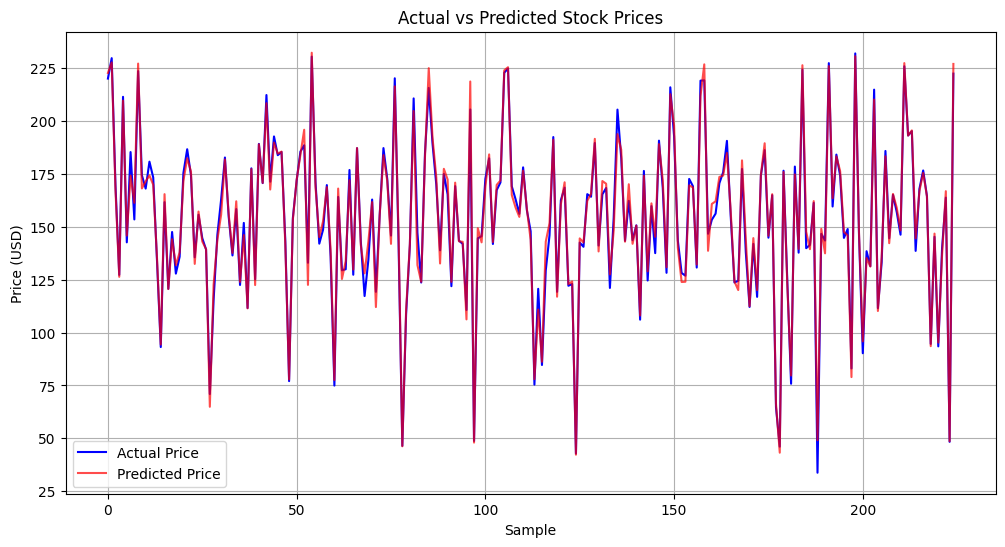

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual Price', color='blue')
plt.plot(predictions, label='Predicted Price', color='red', alpha=0.7)
plt.xlabel('Sample')
plt.ylabel('Price (USD)')
plt.title('Actual vs Predicted Stock Prices')
plt.legend()
plt.grid(True)
plt.show()

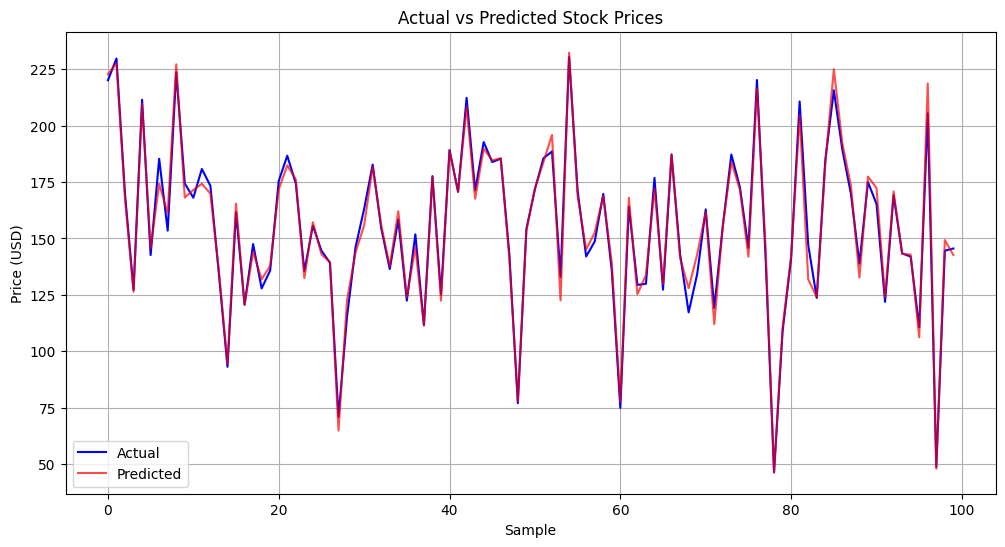

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:100], label='Actual', color='blue')
plt.plot(predictions[:100], label='Predicted', color='red', alpha=0.7)
plt.xlabel('Sample')
plt.ylabel('Price (USD)')
plt.title('Actual vs Predicted Stock Prices')
plt.legend()
plt.grid(True)
plt.show()

In [33]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

               Feature  Importance
0          close_lag_1    0.720542
1                 MA20    0.264840
3                 MACD    0.004611
2                  RSI    0.002094
8        article_count    0.001252
11  Sentiment_7day_avg    0.001252
10     Sentiment_lag_2    0.001065
9      Sentiment_lag_1    0.001021
5   Positive_Sentiment    0.000929
7    Neutral_Sentiment    0.000823
6   Negative_Sentiment    0.000786
4            Sentiment    0.000785


In [ ]:
plt.figure(figsize=(8, 5))
plt.barh(importance['Feature'], importance['Importance'], color='steelblue')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.grid(True, axis='x')
plt.show()